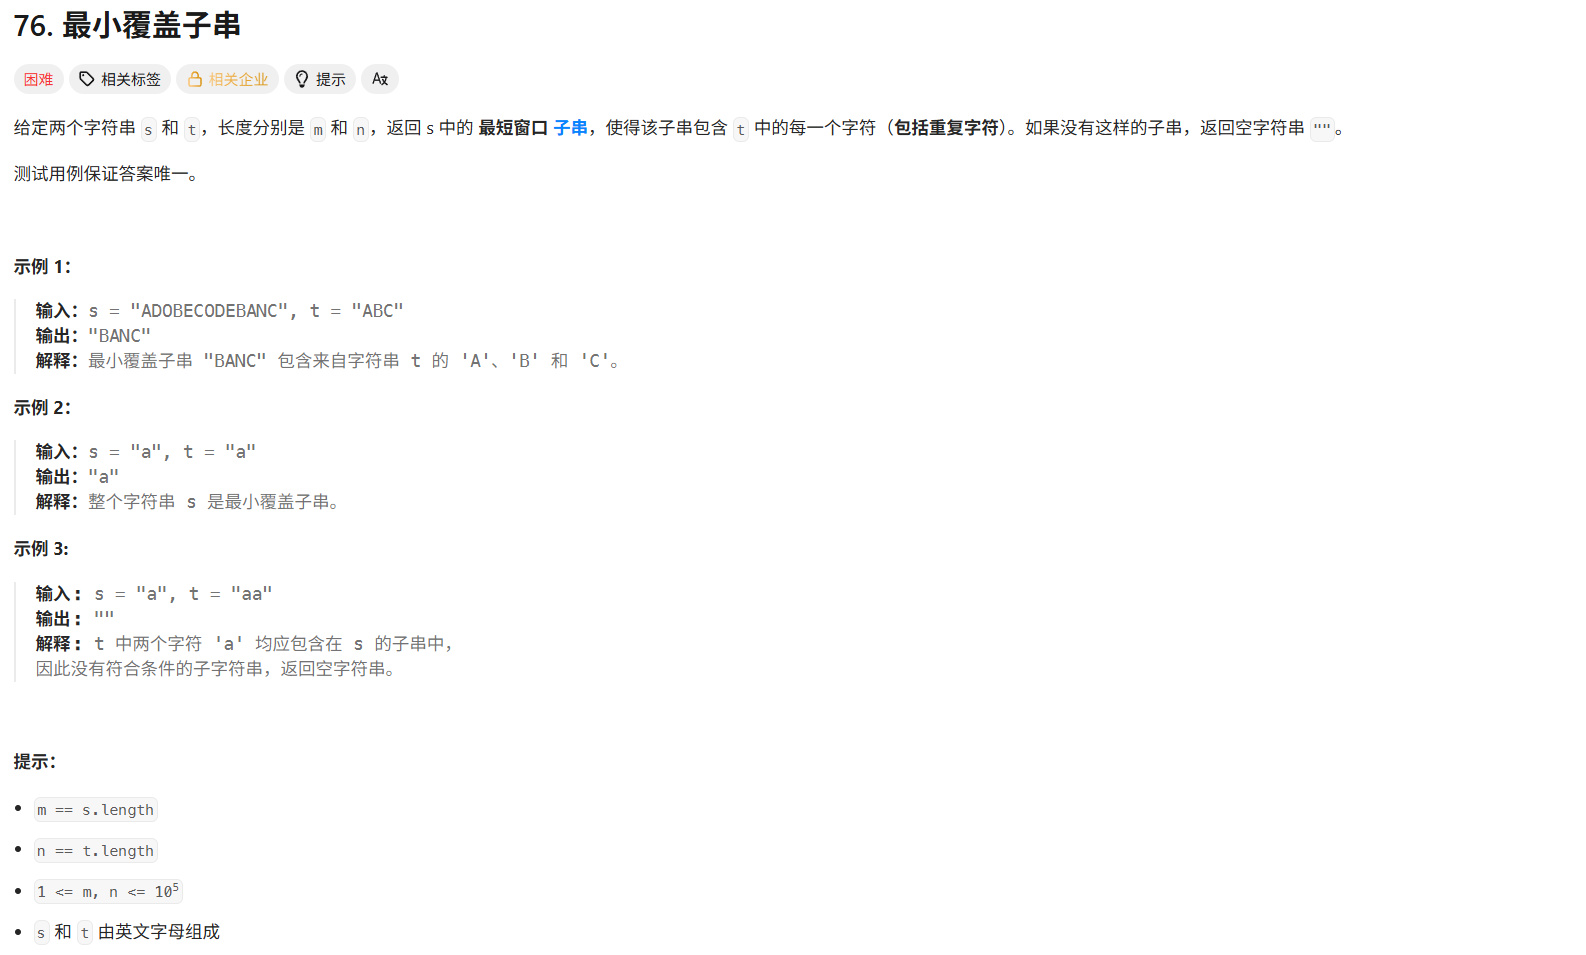

In [ ]:
class Solution:
    def minWindow(self, s: str, t: str) -> str:
        if not s or not t:
            return ""
        
        # 构建 t 的字符频次需求（不要修改它！）
        t_dict = {}
        for char in t:
            t_dict[char] = t_dict.get(char, 0) + 1
        
        need = len(t_dict)          # t 中有多少种不同的字符
        have = 0                    # 当前窗口满足了多少种字符的需求
        window = {}                 # 当前窗口中各字符的频次
        left = 0
        min_len = float('inf')
        ans = ""

        for right, char in enumerate(s):
            # 扩展右边界
            if char in t_dict:
                window[char] = window.get(char, 0) + 1
                # 如果该字符数量刚好达到需求，说明这一种字符“达标”了
                if window[char] == t_dict[char]:
                    have += 1

            # 尝试收缩左边界：只要当前窗口是可行的（have == need），就收缩
            while have == need and left <= right:
                # 更新答案
                if right - left + 1 < min_len:
                    min_len = right - left + 1
                    ans = s[left:right+1]
                
                # 收缩左边界
                left_char = s[left]
                if left_char in t_dict:
                    window[left_char] -= 1
                    # 如果收缩后该字符数量不足，则 have 减 1
                    if window[left_char] < t_dict[left_char]:
                        have -= 1
                left += 1

        return ans